In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

In [3]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [4]:
import os

dataset_path = "../dataset"

for root, dirs, files in os.walk(dataset_path):
    print(root)
    print("Files:", len(files))
    print()

../dataset
Files: 0

../dataset\mrlEyes_2018_01
Files: 2

../dataset\mrlEyes_2018_01\s0001
Files: 3242

../dataset\mrlEyes_2018_01\s0002
Files: 1114

../dataset\mrlEyes_2018_01\s0003
Files: 679

../dataset\mrlEyes_2018_01\s0004
Files: 1069

../dataset\mrlEyes_2018_01\s0005
Files: 736

../dataset\mrlEyes_2018_01\s0006
Files: 1012

../dataset\mrlEyes_2018_01\s0007
Files: 624

../dataset\mrlEyes_2018_01\s0008
Files: 832

../dataset\mrlEyes_2018_01\s0009
Files: 387

../dataset\mrlEyes_2018_01\s0010
Files: 399

../dataset\mrlEyes_2018_01\s0011
Files: 1648

../dataset\mrlEyes_2018_01\s0012
Files: 8728

../dataset\mrlEyes_2018_01\s0013
Files: 3605

../dataset\mrlEyes_2018_01\s0014
Files: 8884

../dataset\mrlEyes_2018_01\s0015
Files: 1132

../dataset\mrlEyes_2018_01\s0016
Files: 1889

../dataset\mrlEyes_2018_01\s0017
Files: 1648

../dataset\mrlEyes_2018_01\s0018
Files: 4410

../dataset\mrlEyes_2018_01\s0019
Files: 6175

../dataset\mrlEyes_2018_01\s0020
Files: 704

../dataset\mrlEyes_2018_01\s0

In [5]:
subject_path = "../dataset/mrlEyes_2018_01/s0001"

files = os.listdir(subject_path)

for file in files[:20]:
    print(file)

s0001_00001_0_0_0_0_0_01.png
s0001_00002_0_0_0_0_0_01.png
s0001_00003_0_0_0_0_0_01.png
s0001_00004_0_0_0_0_0_01.png
s0001_00005_0_0_0_0_0_01.png
s0001_00006_0_0_0_0_0_01.png
s0001_00007_0_0_0_0_0_01.png
s0001_00008_0_0_0_0_0_01.png
s0001_00009_0_0_0_0_0_01.png
s0001_00010_0_0_0_0_0_01.png
s0001_00011_0_0_0_0_0_01.png
s0001_00012_0_0_0_0_0_01.png
s0001_00013_0_0_0_0_0_01.png
s0001_00014_0_0_0_0_0_01.png
s0001_00015_0_0_0_0_0_01.png
s0001_00016_0_0_0_0_0_01.png
s0001_00017_0_0_0_0_0_01.png
s0001_00018_0_0_0_0_0_01.png
s0001_00019_0_0_0_0_0_01.png
s0001_00020_0_0_0_0_0_01.png


In [6]:
dataset_path = "../dataset/mrlEyes_2018_01"

data = []

for subject in os.listdir(dataset_path):
    subject_path = os.path.join(dataset_path, subject)

    if os.path.isdir(subject_path):
        for file in os.listdir(subject_path):
            if file.endswith(".png"):
                parts = file.replace(".png", "").split("_")

                data.append({
                    "file_path": os.path.join(subject_path, file),
                    "subject": parts[0],
                    "gender": int(parts[2]),
                    "glasses": int(parts[3]),
                    "eye_state": int(parts[4]),
                    "reflection": int(parts[5]),
                    "lighting": int(parts[6]),
                    "sensor": parts[7]
                })

df = pd.DataFrame(data)

df.head()

,file_path,subject,gender,glasses,eye_state,reflection,lighting,sensor
0,../dataset/mrlEyes_2018_01\s0001\s0001_00001_0...,s0001,0,0,0,0,0,01
1,../dataset/mrlEyes_2018_01\s0001\s0001_00002_0...,s0001,0,0,0,0,0,01
2,../dataset/mrlEyes_2018_01\s0001\s0001_00003_0...,s0001,0,0,0,0,0,01
3,../dataset/mrlEyes_2018_01\s0001\s0001_00004_0...,s0001,0,0,0,0,0,01
4,../dataset/mrlEyes_2018_01\s0001\s0001_00005_0...,s0001,0,0,0,0,0,01


In [7]:
df.shape

(84898, 8)

In [8]:
df["eye_state"].value_counts()

eye_state
1    42952
0    41946
Name: count, dtype: int64

In [9]:
df["eye_state"].value_counts(normalize=True)

eye_state
1    0.505925
0    0.494075
Name: proportion, dtype: float64

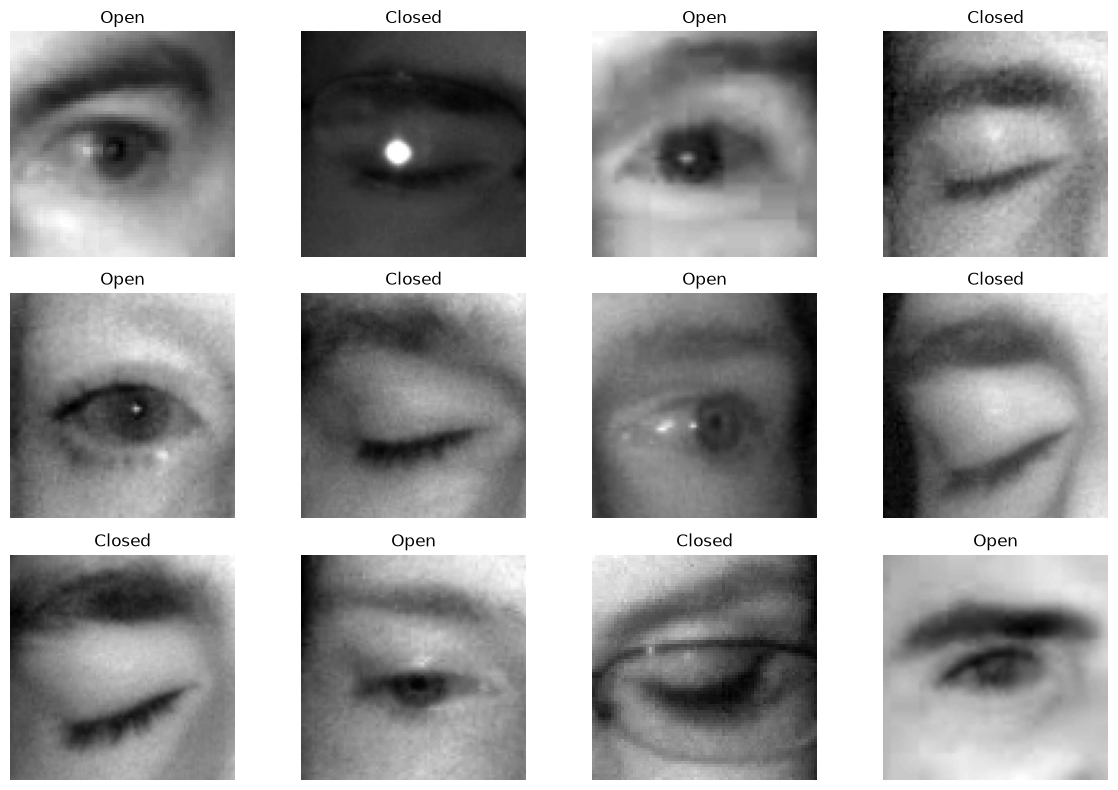

In [10]:
samples = df.sample(12, random_state=42)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(samples.iterrows()):
    image = Image.open(row["file_path"])

    plt.subplot(3, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title("Open" if row["eye_state"] == 1 else "Closed")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 1. Check Image Mode / Format

Examine the color mode (e.g., grayscale `'L'` vs. `'RGB'`), file encoding format, number of channels, and bit-depth across a representative sample of images.

In [12]:
for path in df["file_path"].head(5):
    image = Image.open(path)
    print("Mode:", image.mode, "| Format:", image.format)

Mode: L | Format: PNG
Mode: L | Format: PNG
Mode: L | Format: PNG
Mode: L | Format: PNG
Mode: L | Format: PNG


**Observations & Technical Implications:**
- **Mode:** All images are in `'L'` mode (8-bit single-channel grayscale, pixel values in `[0, 255]`).
- **Format:** All files use lossless PNG encoding.
- **Channels:** Exactly 1 channel (grayscale).
- **CNN Architecture:** The neural network input layer should expect shape `(height, width, 1)` rather than 3 RGB channels, significantly reducing model parameters and computational overhead.

## 2. Check Actual Image Dimensions

Analyze the variation in image resolutions across the dataset, verify aspect ratios, and visualize the distribution of widths and heights.

In [13]:
sample_paths = df["file_path"].sample(2000, random_state=42)

widths = []
heights = []

for path in sample_paths:
    image = Image.open(path)
    w, h = image.size
    widths.append(w)
    heights.append(h)

dim_df = pd.DataFrame({
    "width": widths,
    "height": heights
})

print("Are all images square?",
      (dim_df["width"] == dim_df["height"]).all())

print("\nDimension Summary:")
display(dim_df.describe())

Are all images square? True

Dimension Summary:


,width,height
count,2000.000000,2000.000000
mean,92.711500,92.711500
std,24.606849,24.606849
min,54.000000,54.000000
25%,75.000000,75.000000
50%,87.000000,87.000000
75%,106.000000,106.000000
max,254.000000,254.000000


C:\Users\Anand Patidar\AppData\Local\Temp\ipykernel_18676\3070465417.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(dim_df["width"], vert=False)


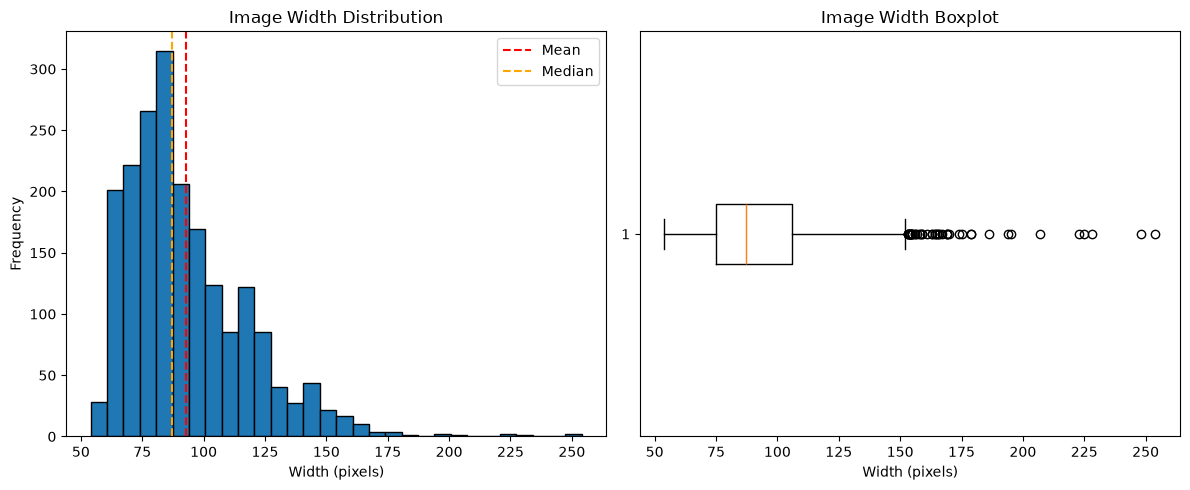

In [17]:
# Visualize image dimensions
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.hist(dim_df["width"], bins=30, edgecolor="black")
plt.axvline(dim_df["width"].mean(), linestyle="--", label="Mean",color="red")
plt.axvline(dim_df["width"].median(), linestyle="--", label="Median",color="orange")
plt.title("Image Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(dim_df["width"], vert=False)
plt.title("Image Width Boxplot")
plt.xlabel("Width (pixels)")

plt.tight_layout()
plt.show()

**Observations & Preprocessing Decisions:**
- All eye crops are square (`width == height`, aspect ratio = 1.0).
- Dimensions vary widely, ranging from 54x54 px to 254x254 px, with a median of 87x87 px and mean of 92.7 px.
- **Target Resolution:** CNN architectures require fixed input dimensions. A target size of **80x80** (or **64x64**) is recommended as it sits near the median crop size, preserving vital pupil landmarks and eyelid contours without excessive upscaling or downscaling distortion.

## 3. Analyze Subjects

Investigate subject-level characteristics: image counts per subject, class balance (open vs. closed eyes) per subject, gender representation, glasses usage, reflections, and lighting conditions.

In [18]:
# Aggregate statistics per subject
subject_summary = df.groupby("subject").agg(
    total_images=("eye_state", "count"),
    open_eyes=("eye_state", lambda x: (x == 1).sum()),
    closed_eyes=("eye_state", lambda x: (x == 0).sum()),
    open_ratio=("eye_state", "mean"),
    gender=("gender", "first"),
    glasses=("glasses", lambda x: x.mode()[0]),
    dominant_sensor=("sensor", lambda x: x.mode()[0])
).reset_index()

print(f"Total Unique Subjects: {len(subject_summary)}")
print(f"Min images per subject: {subject_summary['total_images'].min()} ({subject_summary.loc[subject_summary['total_images'].idxmin(), 'subject']})")
print(f"Max images per subject: {subject_summary['total_images'].max()} ({subject_summary.loc[subject_summary['total_images'].idxmax(), 'subject']})")
print(f"Mean images per subject: {subject_summary['total_images'].mean():.1f}")
print(f"Median images per subject: {subject_summary['total_images'].median():.1f}")

display(subject_summary)

Total Unique Subjects: 37
Min images per subject: 382 (s0022)
Max images per subject: 10257 (s0037)
Mean images per subject: 2294.5
Median images per subject: 1114.0


,subject,total_images,open_eyes,closed_eyes,open_ratio,gender,glasses,dominant_sensor
0,s0001,3242,1401,1841,0.432141,0,0,01
1,s0002,1114,107,1007,0.096050,0,0,01
2,s0003,679,120,559,0.176730,0,0,01
3,s0004,1069,0,1069,0.000000,0,0,01
4,s0005,736,28,708,0.038043,0,0,01
5,s0006,1012,1,1011,0.000988,0,1,01
6,s0007,624,11,613,0.017628,0,0,01
7,s0008,832,0,832,0.000000,0,1,01
8,s0009,387,24,363,0.062016,0,0,01
9,s0010,399,68,331,0.170426,0,0,01


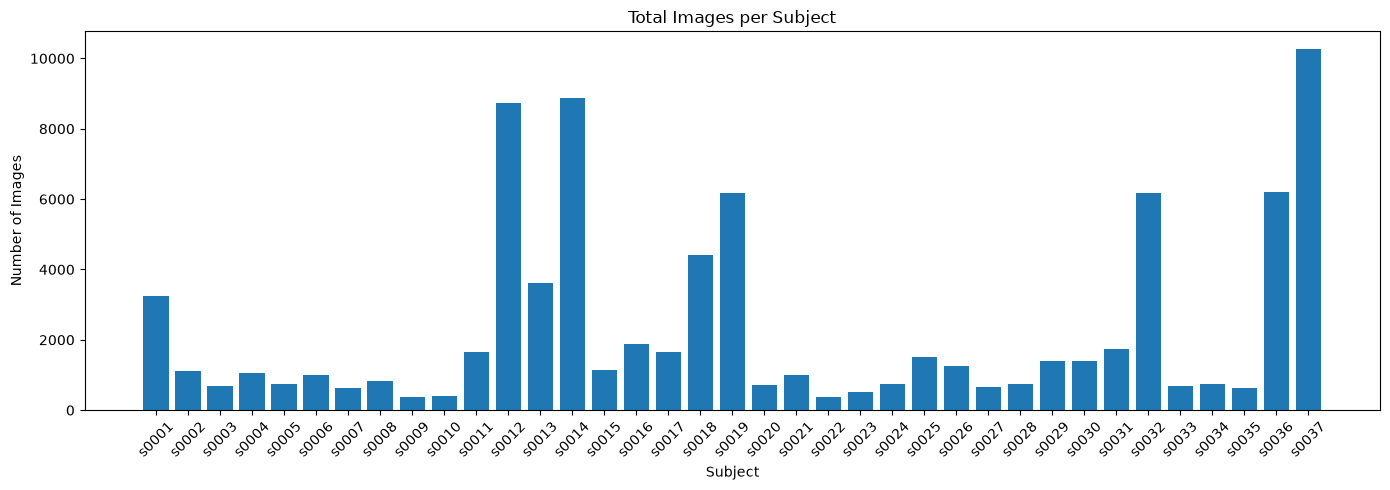

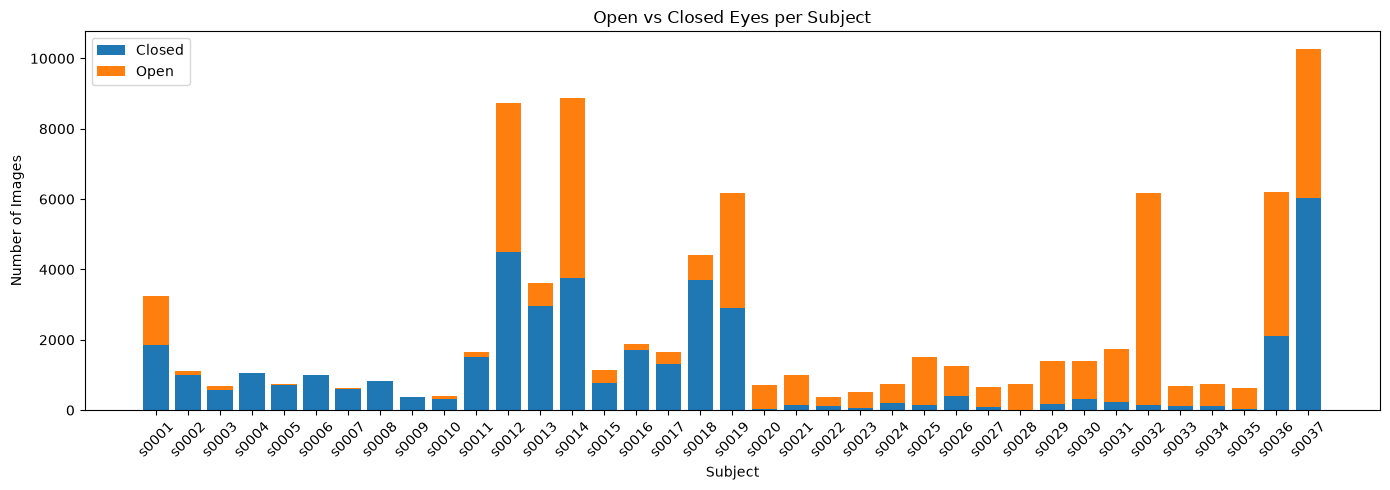

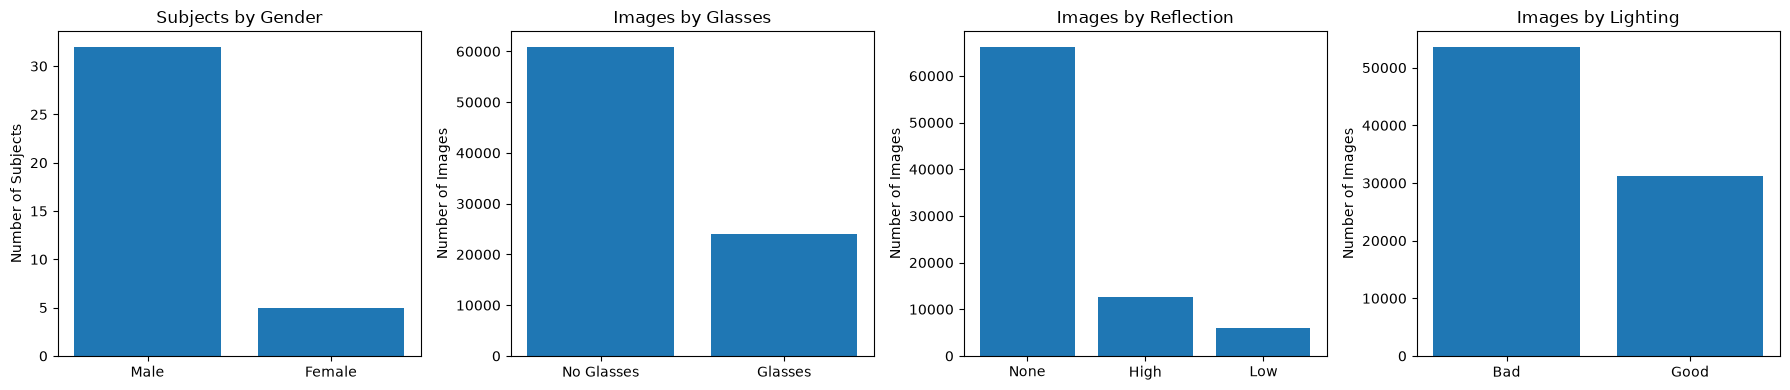

In [20]:
# 1. Total Images per Subject
plt.figure(figsize=(14, 5))
plt.bar(subject_summary["subject"], subject_summary["total_images"])
plt.title("Total Images per Subject")
plt.xlabel("Subject")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 2. Open vs Closed Eyes per Subject
plt.figure(figsize=(14, 5))
plt.bar(subject_summary["subject"], subject_summary["closed_eyes"], label="Closed")
plt.bar(subject_summary["subject"], subject_summary["open_eyes"],
        bottom=subject_summary["closed_eyes"], label="Open")

plt.title("Open vs Closed Eyes per Subject")
plt.xlabel("Subject")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# 3–6. Other Subject Attributes
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Gender
gender_counts = subject_summary["gender"].map({
    0: "Male",
    1: "Female"
}).value_counts()

axes[0].bar(gender_counts.index, gender_counts.values)
axes[0].set_title("Subjects by Gender")
axes[0].set_ylabel("Number of Subjects")


# Glasses
glasses_counts = df["glasses"].map({
    0: "No Glasses",
    1: "Glasses"
}).value_counts()

axes[1].bar(glasses_counts.index, glasses_counts.values)
axes[1].set_title("Images by Glasses")
axes[1].set_ylabel("Number of Images")


# Reflection
reflection_counts = df["reflection"].map({
    0: "None",
    1: "Low",
    2: "High"
}).value_counts()

axes[2].bar(reflection_counts.index, reflection_counts.values)
axes[2].set_title("Images by Reflection")
axes[2].set_ylabel("Number of Images")


# Lighting
lighting_counts = df["lighting"].map({
    0: "Bad",
    1: "Good"
}).value_counts()

axes[3].bar(lighting_counts.index, lighting_counts.values)
axes[3].set_title("Images by Lighting")
axes[3].set_ylabel("Number of Images")

plt.tight_layout()
plt.show()

**Critical Subject-Level Findings:**
1. **Severe Subject Imbalance:** Total images per subject range from 382 (`s0022`) to 10,257 (`s0037`) - more than a 26x discrepancy.
2. **Session-Level Class Skew:**
   - Several subjects consist almost entirely of closed eyes (e.g., `s0004` and `s0008` have 0 open eyes; `s0006` has only 1 open eye out of 1,012).
   - In contrast, other subjects consist predominantly of open eyes (e.g., `s0020`, `s0028`, and `s0032` have >96% open eyes).
3. **The Data Leakage Risk:**
   - Standard random shuffling would scatter images of each subject across train, validation, and test sets.
   - Because subjects have distinct facial backgrounds, skin tones, and lighting conditions, a model trained with random splits easily overfits to identity features rather than eyelid states.
   - Therefore, a **Subject-Wise (Subject-Independent) Split** is required to guarantee reliable, leak-free evaluation on unseen drivers.

## 4. Subject-wise Train/Validation/Test Split

To prevent data leakage and evaluate real-world generalization, we perform a **Subject-Independent Split**.
Each subject is allocated exclusively to **Train**, **Validation**, or **Test**.

The partitioning strategy achieves:
- ~**70% Train**, ~**15% Validation**, and ~**15% Test** dataset proportion.
- **Balanced Class Distribution** (~50.5% open eyes in every split).
- **Demographic Representation** (female subjects and glasses wearers represented across all sets).

In [21]:
# Define Subject Partitioning
train_subjects = [
    's0001', 's0004', 's0005', 's0007', 's0010', 's0011', 's0012', 's0013', 
    's0016', 's0018', 's0019', 's0020', 's0021', 's0022', 's0023', 's0025', 
    's0026', 's0028', 's0029', 's0031', 's0032', 's0033', 's0034', 's0037'
]

val_subjects = [
    's0003', 's0009', 's0014', 's0017', 's0024', 's0027'
]

test_subjects = [
    's0002', 's0006', 's0008', 's0015', 's0030', 's0035', 's0036'
]

# Check that subjects do not overlap
print("Train ∩ Val:", set(train_subjects) & set(val_subjects))
print("Train ∩ Test:", set(train_subjects) & set(test_subjects))
print("Val ∩ Test:", set(val_subjects) & set(test_subjects))

# Assign split to each image
split_map = {}

for s in train_subjects:
    split_map[s] = "train"

for s in val_subjects:
    split_map[s] = "val"

for s in test_subjects:
    split_map[s] = "test"

df["split"] = df["subject"].map(split_map)

print("\nImages in each split:")
print(df["split"].value_counts())

Train ∩ Val: set()
Train ∩ Test: set()
Val ∩ Test: set()

Images in each split:
split
train    59574
val      13015
test     12309
Name: count, dtype: int64


In [23]:
# Aggregate and display split statistics
split_summary = df.groupby("split").agg(
    num_subjects=("subject", "nunique"),
    total_images=("eye_state", "count"),
    open_count=("eye_state", lambda x: (x == 1).sum()),
    closed_count=("eye_state", lambda x: (x == 0).sum()),
    open_pct=("eye_state", lambda x: (x == 1).mean() * 100),
    male_images=("gender", lambda x: (x == 0).sum()),
    female_images=("gender", lambda x: (x == 1).sum()),
    with_glasses=("glasses", lambda x: (x == 1).sum())
).loc[["train", "val", "test"]]

split_summary["split_pct"] = (split_summary["total_images"] / len(df) * 100).round(2)
split_summary["open_pct"] = split_summary["open_pct"].round(2)

print("=== Subject-Wise Split Summary Table ===")
display(split_summary)

=== Subject-Wise Split Summary Table ===


,num_subjects,total_images,open_count,closed_count,open_pct,male_images,female_images,with_glasses,split_pct
split,,,,,,,,,
train,24,59574,30016,29558,50.38,45690,13884,16566,70.17
val,6,13015,6709,6306,51.55,11367,1648,2427,15.33
test,7,12309,6227,6082,50.59,6116,6193,5008,14.50


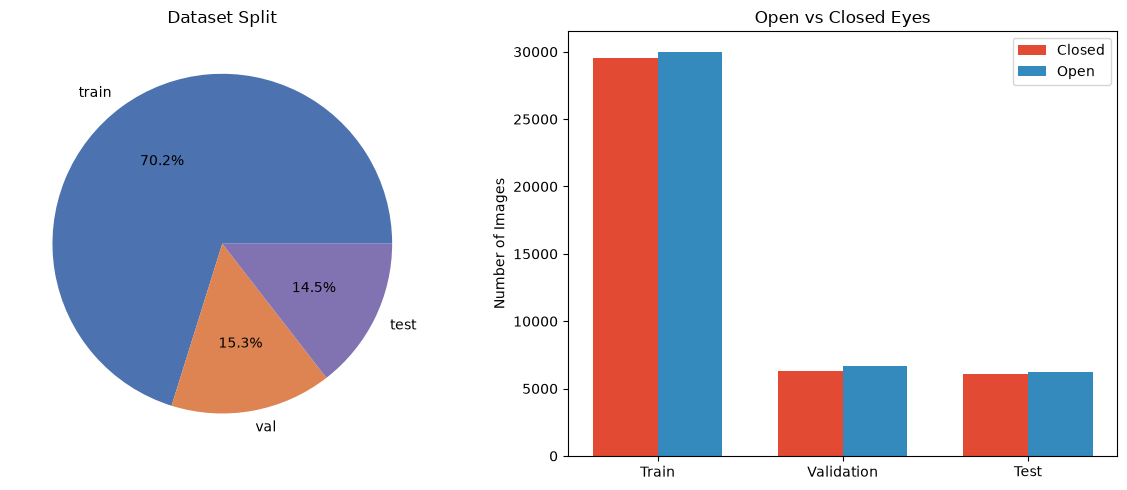

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Dataset Split
counts = split_summary["total_images"]

axes[0].pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452", "#8172B2"]
)
axes[0].set_title("Dataset Split")


# 2. Open vs Closed Eyes
split_names = ["train", "val", "test"]

closed = split_summary.loc[split_names, "closed_count"]
open_ = split_summary.loc[split_names, "open_count"]

x = np.arange(3)
width = 0.35

axes[1].bar(x - width/2, closed, width, label="Closed", color="#E24A33")
axes[1].bar(x + width/2, open_, width, label="Open", color="#348ABD")

axes[1].set_title("Open vs Closed Eyes")
axes[1].set_xticks(x)
axes[1].set_xticklabels(["Train", "Validation", "Test"])
axes[1].set_ylabel("Number of Images")
axes[1].legend()

plt.tight_layout()
plt.show()

**Split Validation Highlights:**
- **Zero Subject Overlap:** Complete isolation between Train, Validation, and Test subjects ($Train \cap Val \cap Test = \emptyset$).
- **Preserved Class Balance:**
  - Train: 50.4% Open / 49.6% Closed
  - Validation: 51.5% Open / 48.5% Closed
  - Test: 50.6% Open / 49.4% Closed
- **Target Proportions:** Train (70.2%), Validation (15.3%), Test (14.5%).
- **Demographic Balance:** Both male and female subjects and glasses wearers are present across all three splits.

## 5. Final Dataset Summary

### 1. Dataset Overview Key Metrics

In [25]:
summary = {
    "Total Images": len(df),
    "Total Subjects": df["subject"].nunique(),
    "Image Format": "PNG",
    "Color Mode": "Grayscale",
    "Channels": 1,
    "Image Size Range": f"{dim_df['width'].min()} × {dim_df['width'].max()} px",
    "Median Image Size": f"{dim_df['width'].median():.0f} × {dim_df['width'].median():.0f} px",
    "Open Eyes": f"{(df['eye_state'] == 1).mean() * 100:.1f}%",
    "Closed Eyes": f"{(df['eye_state'] == 0).mean() * 100:.1f}%",
    "Train Images": split_summary.loc["train", "total_images"],
    "Validation Images": split_summary.loc["val", "total_images"],
    "Test Images": split_summary.loc["test", "total_images"],
    "Model Input Size": "80 × 80 × 1"
}

summary_table = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

display(summary_table)

,Metric,Value
0,Total Images,84898
1,Total Subjects,37
2,Image Format,PNG
3,Color Mode,Grayscale
4,Channels,1
5,Image Size Range,54 × 254 px
6,Median Image Size,87 × 87 px
7,Open Eyes,50.6%
8,Closed Eyes,49.4%
9,Train Images,59574


### 2. Key Insights & Preprocessing Guidelines for Model Development

1. **Input Preprocessing Pipeline:**
   - **Single-Channel Grayscale:** Images should be loaded and processed with shape `(80, 80, 1)`, eliminating unnecessary color-channel computation.
   - **Uniform Resizing:** Standardizing to **80x80** (or **64x64**) pixels aligns closely with the median crop size (~87 px), preserving fine eyelid boundaries and pupil position without excessive distortion.
   - **Pixel Normalization:** Scale pixel intensities from `[0, 255]` to `[0.0, 1.0]` (or zero-mean standardization).

2. **Data Augmentation Strategy:**
   - **Safe Transforms:** Slight rotations (±10 degrees), subtle horizontal/vertical translations (±5%), and mild brightness/contrast adjustments.
   - **Transforms to Avoid:** Avoid vertical flipping or extreme shearing that could distort natural eye anatomy.

3. **Evaluation Strategy for Driver Safety:**
   - **Subject-Independent Testing:** Strict evaluation on the held-out **Test split** (7 unseen subjects) ensures true generalization to new drivers.
   - **Safety-Critical Focus (Recall on Closed Eyes):** In a driver monitoring system, failing to detect closed eyes (false negative for drowsiness) poses a critical safety risk. Training and threshold tuning must prioritize **Recall / Sensitivity for Closed Eyes** along with **F1-Score** and **ROC-AUC**.